In [1]:
pip install pydub

In [ ]:
#To make songs into snippets
from pydub import AudioSegment
import os

def split_mp3(source_folder, target_folder, chunk_length_ms=10000):
    # Ensure target folder exists
    if not os.path.exists(target_folder):
        os.makedirs(target_folder)

    # Iterate over all files in the source folder
    for filename in os.listdir(source_folder):
        if filename.endswith('.mp3'):
            path = os.path.join(source_folder, filename)
            audio = AudioSegment.from_mp3(path)

            # Calculate the number of chunks
            length_ms = len(audio)
            number_of_chunks = (length_ms // chunk_length_ms) + 1

            for i in range(number_of_chunks):
                start_ms = i * chunk_length_ms
                end_ms = min((i + 1) * chunk_length_ms, length_ms)

                # Create chunk
                chunk = audio[start_ms:end_ms]

                # Pad with silence if the chunk is less than the chunk length
                if len(chunk) < chunk_length_ms:
                    chunk += AudioSegment.silent(duration=chunk_length_ms - len(chunk))

                # Export chunk
                chunk_name = f"{filename[:-4]}_snippet_{i}.mp3"
                chunk.export(os.path.join(target_folder, chunk_name), format="mp3")

# Usage
source_folder = '/content/drive/MyDrive/Progect/Not_Progressive_Rock'
target_folder = '/content/drive/MyDrive/Progect/Not_Progressive_Rock_Cuts'
split_mp3(source_folder, target_folder)

In [ ]:
pip install librosa

AttributeError: module 'matplotlib.pyplot' has no attribute 'figsize'

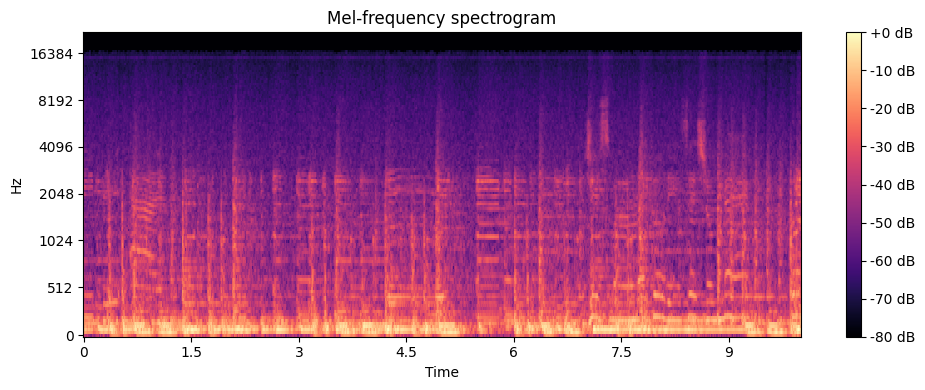

In [ ]:
#To create MFCCs
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
import numpy as np

def create_spectrogram(filename, save_path):
    # Load the audio file
    y, sr = librosa.load(filename, sr=None)

    # Compute the spectrogram (magnitude, power=2)
    S = librosa.feature.melspectrogram(y=y, sr=sr, power=2)

    # Convert to log scale
    S_dB = librosa.power_to_db(S, ref=np.max)

    # Plot
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel-frequency spectrogram')
    plt.tight_layout()

    print(plt.size())
    # Save the figure
    plt.savefig(save_path)
    plt.close()

def process_folder(source_folder, target_folder):
    # Create target folder if it does not exist
    if not os.path.exists(target_folder):
        os.makedirs(target_folder)

    # Process each file in the source folder
    for filename in os.listdir(source_folder):
        if filename.endswith('.mp3'):
            source_file = os.path.join(source_folder, filename)
            target_file = os.path.join(target_folder, f"{os.path.splitext(filename)[0]}_spectrogram.png")
            create_spectrogram(source_file, target_file)

# Usage
source_folder = '/content/drive/MyDrive/Progect/Progressive_Rock_Songs_Cuts'
target_folder = '/content/drive/MyDrive/Progect/Progressive_Rock_Songs_Spectrograms'
process_folder(source_folder, target_folder)

In [13]:
#To Rename files according to their labels.
import os

def rename_files(folder_path, label):
    """
    Renames the files in the specified folder to the format "label_i.ext",
    where i is the index of the file and ext is its original extension.

    Parameters:
    folder_path (str): Path to the folder containing the files to rename.
    label (str): Label to use in the new filenames.
    """
    # List all files in the folder
    files = os.listdir(folder_path)

    # Filter out any non-file entries (like subfolders)
    files = [f for f in files if os.path.isfile(os.path.join(folder_path, f))]

    # Sort the files to maintain a consistent ordering
    files.sort()

    # Loop through all files and rename them
    for i, file_name in enumerate(files):
        # Get the file extension
        extension = os.path.splitext(file_name)[1]

        # Define the new file name using the specified label and the file index
        new_name = f"{label}_{i}{extension}"

        # Define the old and new file paths
        old_file = os.path.join(folder_path, file_name)
        new_file = os.path.join(folder_path, new_name)

        # Rename the file
        os.rename(old_file, new_file)

        print(f"Renamed {file_name} to {new_name}")

# Example usage
folder_path = '/content/drive/MyDrive/Progect/temp'  # Replace './your_folder' with the path to your actual folder
label = 'nonProg'  # Replace 'image' with your desired label
rename_files(folder_path, label)


Renamed Copy of (06) [Alice Cooper] No More Mr. Nice Guy_snippet_0.pt to nonProg_0.pt
Renamed Copy of (06) [Alice Cooper] No More Mr. Nice Guy_snippet_1.pt to nonProg_1.pt
Renamed Copy of (06) [Alice Cooper] No More Mr. Nice Guy_snippet_10.pt to nonProg_2.pt
Renamed Copy of (06) [Alice Cooper] No More Mr. Nice Guy_snippet_11.pt to nonProg_3.pt
Renamed Copy of (06) [Alice Cooper] No More Mr. Nice Guy_snippet_12.pt to nonProg_4.pt
Renamed Copy of (06) [Alice Cooper] No More Mr. Nice Guy_snippet_13.pt to nonProg_5.pt
Renamed Copy of (06) [Alice Cooper] No More Mr. Nice Guy_snippet_14.pt to nonProg_6.pt
Renamed Copy of (06) [Alice Cooper] No More Mr. Nice Guy_snippet_15.pt to nonProg_7.pt
Renamed Copy of (06) [Alice Cooper] No More Mr. Nice Guy_snippet_16.pt to nonProg_8.pt
Renamed Copy of (06) [Alice Cooper] No More Mr. Nice Guy_snippet_17.pt to nonProg_9.pt
Renamed Copy of (06) [Alice Cooper] No More Mr. Nice Guy_snippet_18.pt to nonProg_10.pt
Renamed Copy of (06) [Alice Cooper] No More 

In [14]:
#code to cut and paste files from source to target
import shutil
import os

def move_files(source_dir, target_dir):
    """
    Moves files from the source directory to the target directory.

    Args:
    - source_dir (str): The path to the source directory.
    - target_dir (str): The path to the target directory.
    """
    # Ensure the target directory exists, create it if it doesn't
    os.makedirs(target_dir, exist_ok=True)

    # Get a list of files in the source directory
    files = [f for f in os.listdir(source_dir) if os.path.isfile(os.path.join(source_dir, f))]

    # Move each file to the target directory
    for file in files:
        source_path = os.path.join(source_dir, file)
        target_path = os.path.join(target_dir, file)

        # Move the file
        shutil.move(source_path, target_path)
        print(f"Moved: {file}")

# Example usage
source_directory = '/content/drive/MyDrive/Progect/temp'
target_directory = '/content/drive/MyDrive/Progect/test'
move_files(source_directory, target_directory)


Moved: nonProg_33.pt
Moved: nonProg_32.pt
Moved: nonProg_30.pt
Moved: nonProg_29.pt
Moved: nonProg_28.pt
Moved: nonProg_27.pt
Moved: nonProg_26.pt
Moved: nonProg_25.pt
Moved: nonProg_24.pt
Moved: nonProg_23.pt
Moved: nonProg_22.pt
Moved: nonProg_21.pt
Moved: nonProg_40.pt
Moved: nonProg_39.pt
Moved: nonProg_38.pt
Moved: nonProg_37.pt
Moved: nonProg_36.pt
Moved: nonProg_35.pt
Moved: nonProg_34.pt
Moved: nonProg_31.pt
Moved: nonProg_20.pt
Moved: nonProg_19.pt
Moved: nonProg_10.pt
Moved: nonProg_9.pt
Moved: nonProg_8.pt
Moved: nonProg_7.pt
Moved: nonProg_6.pt
Moved: nonProg_5.pt
Moved: nonProg_4.pt
Moved: nonProg_3.pt
Moved: nonProg_2.pt
Moved: nonProg_18.pt
Moved: nonProg_17.pt
Moved: nonProg_16.pt
Moved: nonProg_15.pt
Moved: nonProg_14.pt
Moved: nonProg_13.pt
Moved: nonProg_12.pt
Moved: nonProg_11.pt
Moved: nonProg_1.pt
Moved: nonProg_0.pt


In [9]:
import os

def delete_png_files(directory):
    """
    Deletes all .png files in the specified directory.

    Args:
    - directory (str): The path to the directory from which to delete .png files.
    """
    # List all files in the directory
    for filename in os.listdir(directory):
        if filename.endswith(".png"):
            file_path = os.path.join(directory, filename)
            # Delete the file
            os.remove(file_path)
            print(f"Deleted: {file_path}")

# Example usage
directory_path = '/content/drive/MyDrive/Progect/validation'
delete_png_files(directory_path)


Deleted: /content/drive/MyDrive/Progect/validation/prog_0.png
Deleted: /content/drive/MyDrive/Progect/validation/prog_1.png
Deleted: /content/drive/MyDrive/Progect/validation/prog_2.png
Deleted: /content/drive/MyDrive/Progect/validation/prog_3.png
Deleted: /content/drive/MyDrive/Progect/validation/prog_4.png
Deleted: /content/drive/MyDrive/Progect/validation/prog_5.png
Deleted: /content/drive/MyDrive/Progect/validation/prog_6.png
Deleted: /content/drive/MyDrive/Progect/validation/prog_7.png
Deleted: /content/drive/MyDrive/Progect/validation/prog_8.png
Deleted: /content/drive/MyDrive/Progect/validation/prog_9.png
Deleted: /content/drive/MyDrive/Progect/validation/prog_10.png
Deleted: /content/drive/MyDrive/Progect/validation/prog_11.png
Deleted: /content/drive/MyDrive/Progect/validation/prog_12.png
Deleted: /content/drive/MyDrive/Progect/validation/prog_13.png
Deleted: /content/drive/MyDrive/Progect/validation/prog_14.png
Deleted: /content/drive/MyDrive/Progect/validation/prog_15.png
De

In [2]:
#To extract MFCC Features into .pt files
import os
import torch
import librosa

def extract_mfcc_features(audio_path, n_mfcc=13, hop_length=512, n_fft=2048):
    """
    Extract MFCC features from an audio file using librosa and return a PyTorch tensor.

    Parameters:
    - audio_path: Path to the audio file.
    - n_mfcc: Number of MFCC features to extract.
    - hop_length: Hop length for FFT.
    - n_fft: Number of bins for FFT.

    Returns:
    - mfccs_tensor: Extracted MFCC features as a PyTorch tensor.
    """
    # Load the audio file
    signal, sr = librosa.load(audio_path, sr=None)

    # Extract MFCC features
    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length, n_fft=n_fft)

    # Transpose the MFCCs to have a shape more suitable for CNN input and convert to PyTorch tensor
    mfccs = mfccs.T
    mfccs_tensor = torch.tensor(mfccs, dtype=torch.float32)

    return mfccs_tensor

def process_audio_files_and_save(directory, n_mfcc=13, hop_length=512, n_fft=2048):
    # Ensure there's a directory to save the tensors
    save_dir = os.path.join(directory, "Not_Progressive_Rock_Cuts_MFCC_Data")
    os.makedirs(save_dir, exist_ok=True)

    # Process each file in the directory
    for filename in os.listdir(directory):
        if filename.endswith(".mp3"):
            # Extract MFCC features
            audio_path = os.path.join(directory, filename)
            mfccs_tensor = extract_mfcc_features(audio_path, n_mfcc=n_mfcc, hop_length=hop_length, n_fft=n_fft)

            # Save the tensor to a .pt file
            tensor_filename = os.path.splitext(filename)[0] + ".pt"
            save_path = os.path.join(save_dir, tensor_filename)
            torch.save(mfccs_tensor, save_path)

# Example usage
directory = "/content/drive/MyDrive/Progect/Not_Progressive_Rock_Cuts"
process_audio_files_and_save(directory)

